**Copied code from the data_loading file to display the projection on the map and the data points for the stations.**


In [21]:
from pathlib import Path
import zipfile
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import random
from shapely.geometry import LineString

In [2]:
GTFS_PATH = Path("../data/raw/GTFS_Copenhagen.zip")

if not GTFS_PATH.exists():
    raise FileNotFoundError(
        "GTFS ZIP not found. Download it as described in README.md"
    )
    
with zipfile.ZipFile(GTFS_PATH, "r") as z:
    stops = pd.read_csv(z.open("GTFS_Copenhagen/stops.txt"))
    routes = pd.read_csv(z.open("GTFS_Copenhagen/routes.txt"))
    shapes = pd.read_csv(z.open("GTFS_Copenhagen/shapes.txt"))
    stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))
    trips = pd.read_csv(z.open("GTFS_Copenhagen/trips.txt"))

/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_83184/146572828.py:12: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(z.open("GTFS_Copenhagen/stop_times.txt"))


In [3]:
# stops filtering for metro only
metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]

# remove the line based on stop_id
metro_stops = metro_stops[metro_stops["stop_id"] != 821004401]

print(len(metro_stops))

44


/var/folders/qh/2gv9htfj0554_hzssc218vg40000gn/T/ipykernel_83184/2102663247.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  metro_stops = stops[stops['stop_name'].str.contains('(Metro)')]


In [4]:
# Stops GeoDataFrame (WGS84)
gdf_stops = gpd.GeoDataFrame(
    metro_stops,
    geometry=gpd.points_from_xy(metro_stops.stop_lon, metro_stops.stop_lat),
    crs="EPSG:4326"
)

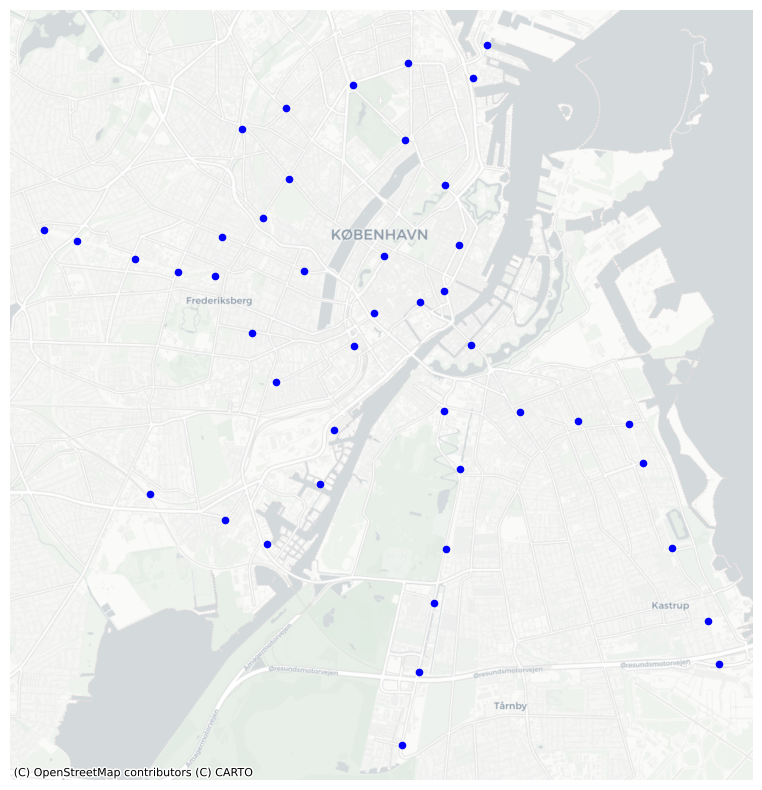

In [5]:
# combine Copenhagen Actual map with stops projection

# Reproject stops to Web Mercator (required by contextily)
gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_stops_3857[gdf_stops_3857['location_type'] == 0].plot(ax=ax, 
                                       markersize=20, 
                                       color='blue') 

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.show()

**Basic Genetic Algorithm, or connections of points by algorithm**

In [6]:
# set parameters for algorithm
n_startnodes = 4
n_maxnodes = 12

n_maxroutes = 4
# prob_mutation = .05 # mutation probability
# n_parents = 20 # how many "parents" for "crossovers" to select per generation
# n_kids = 50 # how many kids to generate for each generation
n_iterations = 100 # how many times to iterate

# find total demand for specific OD set
# total_demand = sum(od.trajcount)

# seed
random.seed(161)

In [7]:
# make the table with generated stop id, name and geometry

stops_table = gdf_stops_3857[["stop_id", "stop_name", "geometry"]]
stops_table.head()

,stop_id,stop_name,geometry
51,8603317,Vestamager St. (Metro),POINT (1399875.659 7483017.289)
52,8603315,Ørestad St. (Metro),POINT (1400331.178 7484922.633)
53,8603312,Sundby St. (Metro),POINT (1401036.832 7488106.615)
54,8603313,Bella Center St. (Metro),POINT (1400725.138 7486696.697)
55,8603310,Islands Brygge St. (Metro),POINT (1400979.948 7491702.202)


In [30]:
# mercator projection for stops
gdf_stops_3857 = gdf_stops.to_crs(epsg=3857)

n = 44

origins = gdf_stops_3857.sample(n=n, replace=True).copy().reset_index(drop=True)
destinations = gdf_stops_3857.sample(n=n, replace=True).copy().reset_index(drop=True)

od = origins[["stop_id","stop_name", "geometry"]].copy()
od = od.rename(columns={"stop_id": "origin_id", "stop_name": "origin_name", "geometry": "origin_geom"})

od["destination_id"] = destinations["stop_id"]
od["destination_name"] = destinations["stop_name"]
od["destination_geom"] = destinations["geometry"]

od = od.set_geometry(od.apply(lambda row: LineString([row.origin_geom, row.destination_geom]), axis=1))

od.head()

,origin_id,origin_name,origin_geom,destination_id,destination_name,destination_geom,geometry
0,8603305,Frederiksberg St. (Metro),POINT (1395024.578 7495216.141),8603322,Lergravsparken St. (Metro),POINT (1404453.116 7491441.499),"LINESTRING (1395024.578 7495216.141, 1404453.1..."
1,8603345,Orientkaj St. (Metro),POINT (1402099.265 7501218.664),8603331,Rådhuspladsen St. (Metro),POINT (1399152.75 7494258.587),"LINESTRING (1402099.265 7501218.664, 1399152.7..."
2,8603341,Nuuks Plads St. (Metro),POINT (1396268.351 7496711.546),8603317,Vestamager St. (Metro),POINT (1399875.659 7483017.289),"LINESTRING (1396268.351 7496711.546, 1399875.6..."
3,8603335,Trianglen St. (Metro),POINT (1399961.709 7498753.607),8603327,Kastrup St. (Metro),POINT (1407827.766 7486242.296),"LINESTRING (1399961.709 7498753.607, 1407827.7..."
4,8603309,Christianshavn St. (Metro),POINT (1401666.567 7493405.97),8603349,Sluseholmen St. (Metro),POINT (1396363.529 7488232.273),"LINESTRING (1401666.567 7493405.97, 1396363.52..."


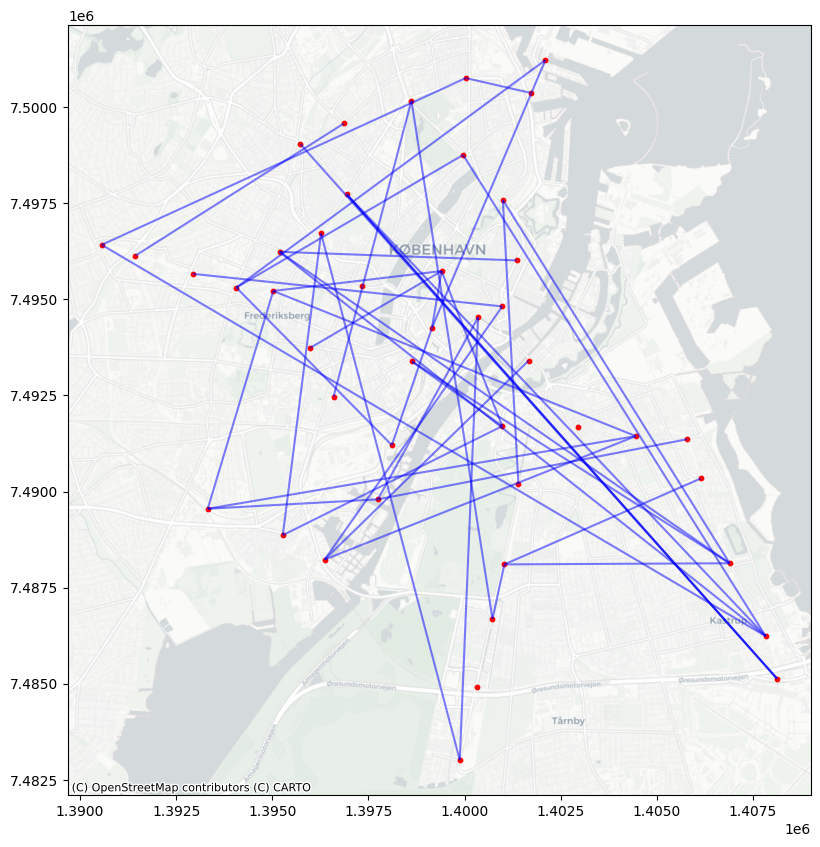

In [31]:
fig, ax = plt.subplots(1,1, figsize = (10,10))
od. plot(ax=ax, color="blue" , alpha=0.5)
gdf_stops_3857.plot(ax=ax, color="red", markersize=10)
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

With this setup, I don't like that some nodes are isolated, and it makes no sense to connect nodes with the greatest distance.

Need to implement max distance of teh edge. 
Check along all nodes in that distance(k-neighbours) and then connected to them. 